# Seasonal Agriculture Performance Analysis
### VOIS AICTE Batch 1 (2026-2027) — Major Project

**Student Name:** _[Your Name]_
**College:** _[Your College Name]_
**AICTE Student ID:** _[Your ID]_

---

## 1. Introduction

This notebook analyzes a dataset of agricultural activities recorded across three cropping seasons in India — **Kharif, Rabi, and Zaid** — spanning multiple states, districts and crops. The dataset captures environmental conditions (rainfall, temperature, humidity, sunlight, soil health), farming practices (irrigation method, fertilizer/pesticide use, seed quality), and economic outcomes (yield, production, cost, revenue, profit, water efficiency, disease/pest risk).

## 2. Problem Statement

Agricultural performance is influenced by seasonal variation in weather, resource availability, and market conditions. Raw data alone does not reveal *how* performance changes across seasons. This project investigates seasonal differences in agricultural performance by identifying patterns, trends, relationships and variations in the dataset.

## 3. Objective

- Explore and clean the dataset
- Examine how performance varies across seasons
- Identify seasonal patterns and relationships between conditions and outcomes
- Compare seasons, crops, states and irrigation methods
- Derive evidence-based insights and recommendations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 40)

df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print("Shape:", df.shape)
df.head()


Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 4. Data Understanding

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [3]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [4]:
print("Seasons:", df['Season'].unique())
print("States :", df['State'].nunique(), "unique states")
print("Crops  :", df['Crop'].unique())
print("Irrigation methods:", df['Irrigation_Method'].unique())


Seasons: <StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str
States : 8 unique states
Crops  : <StringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str
Irrigation methods: <StringArray>
['Drip', 'Flood', 'Rainfed', 'Sprinkler']
Length: 4, dtype: str


## 5. Data Cleaning & Preparation

In [5]:
# Missing values
missing = df.isnull().sum()
print(missing[missing > 0])
print("\nDuplicate rows:", df.duplicated().sum())


Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Duplicate rows: 0


**Cleaning decisions:**
- `Rainfall_mm`, `Soil_Moisture_pct`, `Yield_Tonnes_Ha` have a small number of missing values (~1-1.2% of rows). Since these are numeric and the missingness is random and small, we impute using the **median of the respective Season group** (preserves seasonal character better than a global median).
- No duplicate rows were found.
- We check for unrealistic outliers (e.g. a `Yield_Tonnes_Ha` far above realistic agronomic limits) using the IQR method and cap extreme values rather than dropping rows, to preserve sample size.


In [6]:
df_clean = df.copy()

# Remove exact duplicate rows (identified in the previous cell)
before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df_clean)} duplicate rows -> {len(df_clean)} rows remain")

# Impute missing values with season-wise median
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df_clean[col] = df_clean.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values:", df_clean.isnull().sum().sum())


Dropped 0 duplicate rows -> 4000 rows remain
Remaining missing values: 0


In [7]:
# Outlier check via IQR on key numeric performance columns
key_cols = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR', 'Water_Efficiency_t_per_1000m3']

def iqr_bounds(s):
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

for c in key_cols:
    low, high = iqr_bounds(df_clean[c])
    n_out = ((df_clean[c] < low) | (df_clean[c] > high)).sum()
    print(f"{c}: bounds=({low:.2f}, {high:.2f})  outliers={n_out}")


Yield_Tonnes_Ha: bounds=(-1.62, 5.50)  outliers=302
Production_Tonnes: bounds=(-23.98, 53.36)  outliers=333
Profit_INR: bounds=(-696111.00, 763567.00)  outliers=404
Water_Efficiency_t_per_1000m3: bounds=(-3.57, 10.38)  outliers=322


In [8]:
# Cap extreme outliers (winsorize) on Yield_Tonnes_Ha only, since a few values (>50 t/ha) are agronomically
# implausible for the crops in this dataset and would distort season/crop averages.
low, high = iqr_bounds(df_clean['Yield_Tonnes_Ha'])
before = df_clean['Yield_Tonnes_Ha'].copy()
df_clean['Yield_Tonnes_Ha'] = df_clean['Yield_Tonnes_Ha'].clip(lower=low, upper=high)
print(f"Capped {(before != df_clean['Yield_Tonnes_Ha']).sum()} extreme Yield_Tonnes_Ha values to [{low:.2f}, {high:.2f}]")


Capped 302 extreme Yield_Tonnes_Ha values to [-1.62, 5.50]


In [9]:
# Feature engineering: profit margin, cost per tonne
df_clean['Profit_Margin_pct'] = (df_clean['Profit_INR'] / df_clean['Revenue_INR'].replace(0, np.nan)) * 100
df_clean['Cost_per_Tonne'] = df_clean['Total_Cost_INR'] / df_clean['Production_Tonnes'].replace(0, np.nan)
df_clean[['Profit_Margin_pct', 'Cost_per_Tonne']].describe()


,Profit_Margin_pct,Cost_per_Tonne
count,4000.000000,4000.000000
mean,-45.492178,55624.858332
std,158.085472,54260.608703
min,-1461.851219,568.357511
25%,-60.192762,23032.641975
50%,1.146236,37897.601738
75%,32.885876,64153.096089
max,85.921220,296805.128205


## 6. Univariate Analysis

Examining the distribution of individual numeric and categorical variables before looking at relationships between them.


Yield_Tonnes_Ha: mean=2.10, median=1.73, skew=0.98
Profit_INR: mean=111556.46, median=3673.00, skew=2.42
Rainfall_mm: mean=600.71, median=581.00, skew=0.14


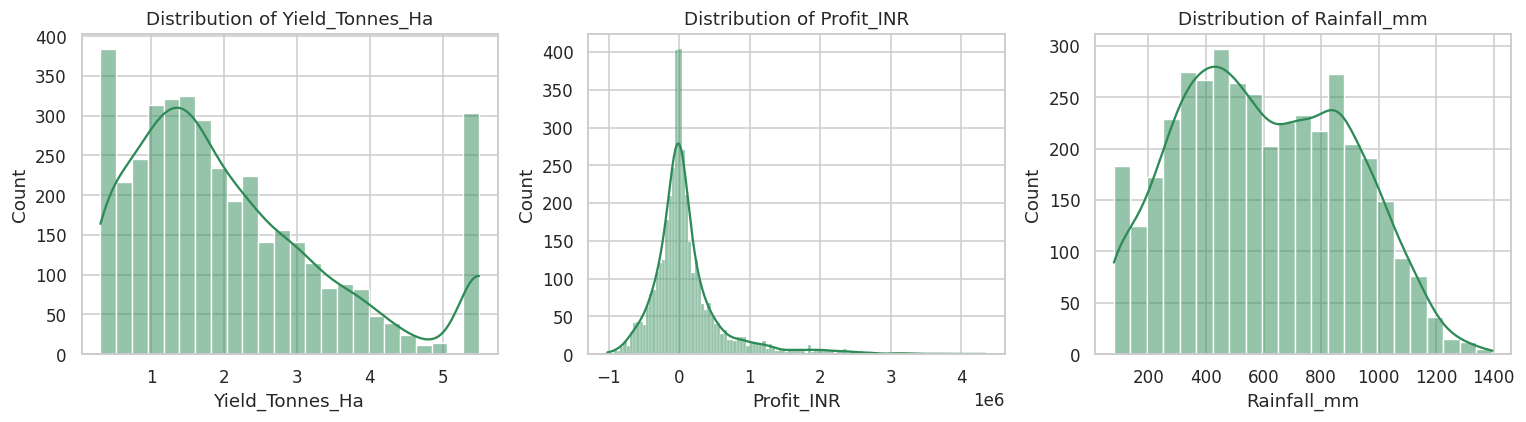

In [10]:
# Univariate: distribution of key numeric outcome variables
num_vars = ['Yield_Tonnes_Ha', 'Profit_INR', 'Rainfall_mm']
fig, axes = plt.subplots(1, 3, figsize=(14,4))
for ax, col in zip(axes, num_vars):
    sns.histplot(df_clean[col], kde=True, ax=ax, color='seagreen')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('imgs/00b_univariate_numeric.png', dpi=150)
plt.show()

for col in num_vars:
    print(f"{col}: mean={df_clean[col].mean():.2f}, median={df_clean[col].median():.2f}, skew={df_clean[col].skew():.2f}")


In [11]:
# Univariate: distribution of key categorical variables
for col in ['Season', 'Crop', 'Irrigation_Method']:
    print(f"--- {col} ---")
    print(df_clean[col].value_counts())
    print()


--- Season ---
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

--- Crop ---
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

--- Irrigation_Method ---
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64



## 7. Seasonal Overview — Record Counts & Distribution

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


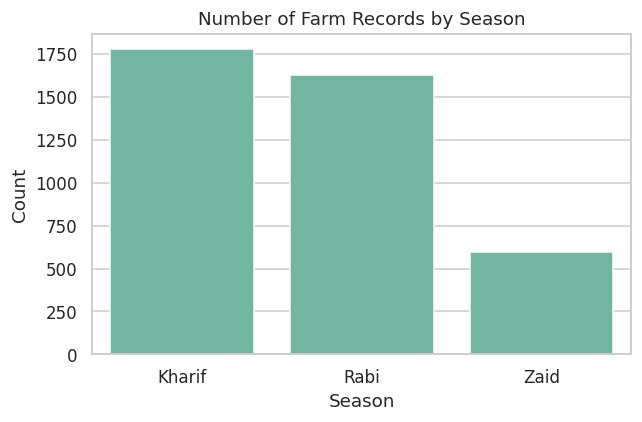

In [12]:
season_order = ['Kharif', 'Rabi', 'Zaid']
counts = df_clean['Season'].value_counts().reindex(season_order)
print(counts)

plt.figure(figsize=(6,4))
sns.barplot(x=counts.index, y=counts.values, order=season_order)
plt.title('Number of Farm Records by Season')
plt.ylabel('Count')
plt.xlabel('Season')
plt.tight_layout()
plt.savefig('imgs/01_season_counts.png', dpi=150)
plt.show()


## 8. Bivariate Analysis — Key Question 1: How does agricultural performance (Yield, Profit) vary across seasons?

Each pair below (Season x Yield, Season x Profit) is a bivariate comparison — one categorical variable against one numeric variable.

In [13]:
perf_by_season = df_clean.groupby('Season')[['Yield_Tonnes_Ha','Production_Tonnes','Profit_INR','Water_Efficiency_t_per_1000m3']].mean().reindex(season_order)
perf_by_season


,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,2.253569,46.311192,178914.647555,5.891834
Rabi,2.032950,41.486712,87689.470191,5.186122
Zaid,1.805236,38.886111,-24804.824916,4.413239


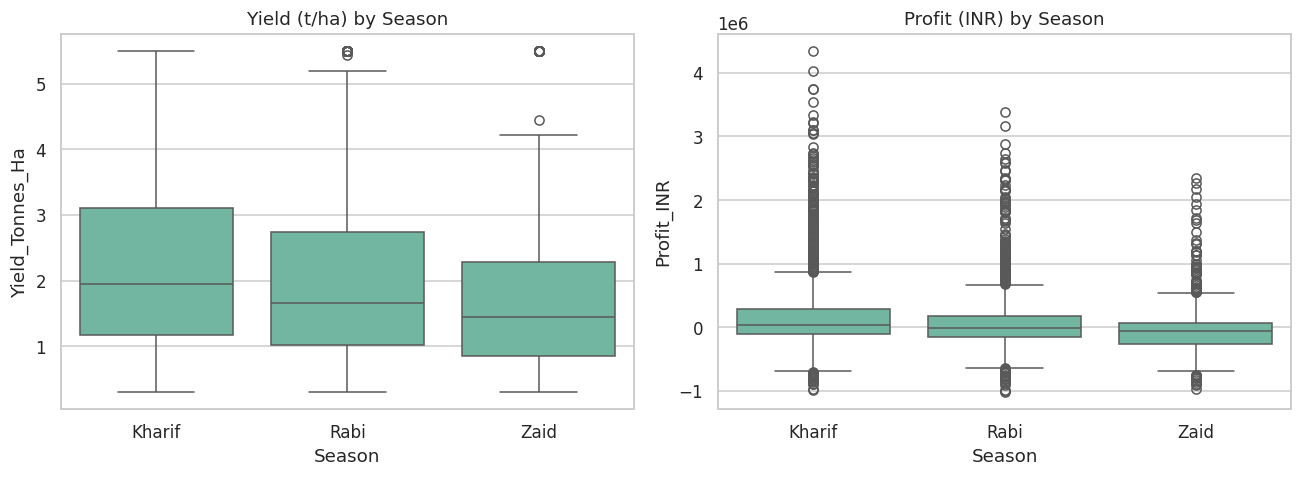

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
sns.boxplot(data=df_clean, x='Season', y='Yield_Tonnes_Ha', order=season_order, ax=axes[0])
axes[0].set_title('Yield (t/ha) by Season')
sns.boxplot(data=df_clean, x='Season', y='Profit_INR', order=season_order, ax=axes[1])
axes[1].set_title('Profit (INR) by Season')
plt.tight_layout()
plt.savefig('imgs/02_yield_profit_by_season.png', dpi=150)
plt.show()


In [15]:
# Statistical test: does mean Yield differ significantly across seasons? (one-way ANOVA)
groups = [df_clean.loc[df_clean['Season']==s, 'Yield_Tonnes_Ha'] for s in season_order]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA on Yield_Tonnes_Ha across seasons: F={f_stat:.3f}, p-value={p_val:.5f}")
print("=> Statistically significant seasonal difference" if p_val < 0.05 else "=> No statistically significant difference")


ANOVA on Yield_Tonnes_Ha across seasons: F=25.422, p-value=0.00000
=> Statistically significant seasonal difference


**Additional bivariate check:** water usage vs. yield (numeric x numeric), independent of season.


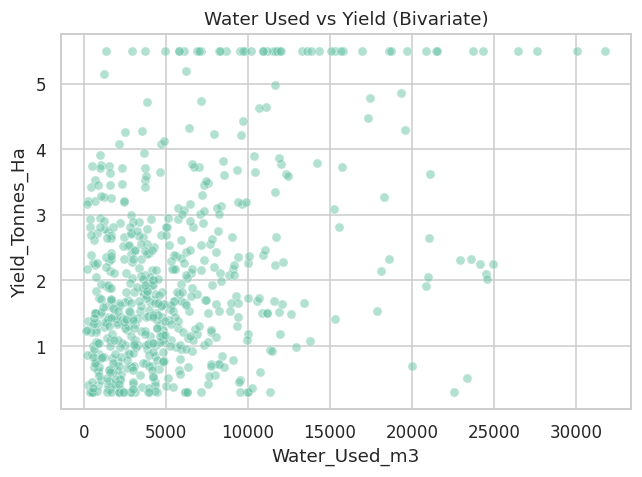

In [16]:
plt.figure(figsize=(6,4.5))
sns.scatterplot(data=df_clean.sample(600, random_state=1), x='Water_Used_m3', y='Yield_Tonnes_Ha', alpha=0.5)
plt.title('Water Used vs Yield (Bivariate)')
plt.tight_layout()
plt.savefig('imgs/02b_water_vs_yield_bivariate.png', dpi=150)
plt.show()


## 9. Key Question 2 — Environmental conditions by season (rainfall, temperature, humidity, sunlight)

In [17]:
env_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_Moisture_pct']
env_by_season = df_clean.groupby('Season')[env_cols].mean().reindex(season_order)
env_by_season


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.112676,28.454019,71.812591,6.793367,31.198426
Rabi,435.937062,23.489183,57.893178,7.589797,24.050215
Zaid,299.123232,31.042088,52.012121,8.178788,19.169024


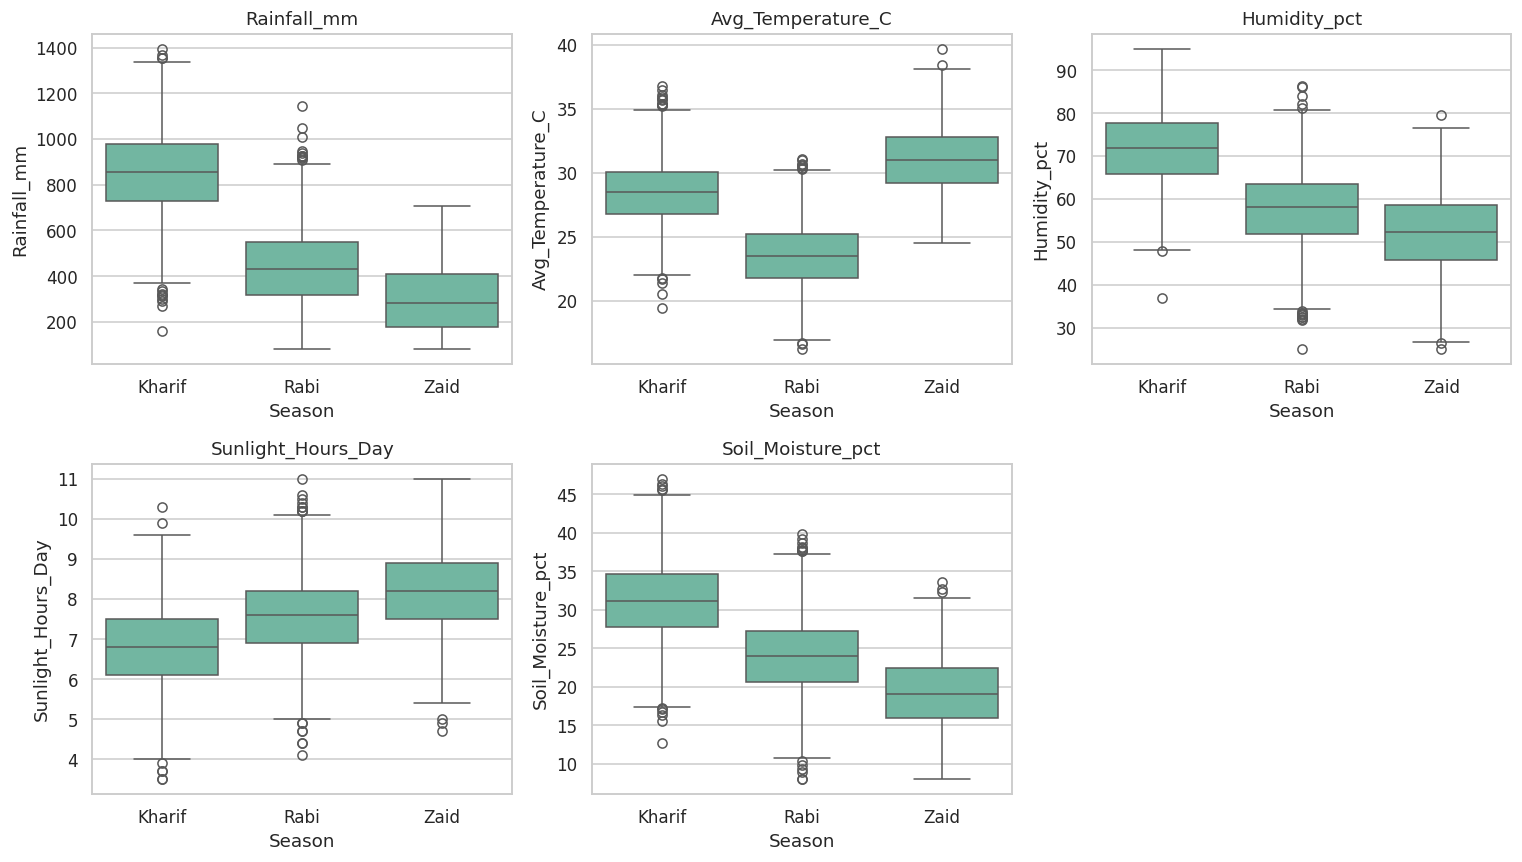

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(14,8))
for ax, col in zip(axes.flat, env_cols):
    sns.boxplot(data=df_clean, x='Season', y=col, order=season_order, ax=ax)
    ax.set_title(col)
axes.flat[-1].axis('off')
plt.tight_layout()
plt.savefig('imgs/03_environment_by_season.png', dpi=150)
plt.show()


## 10. Key Question 3 — Resource usage across seasons (fertilizer, pesticide, water)

In [19]:
res_cols = ['Fertilizer_kg_ha','Pesticide_Litre_ha','Water_Used_m3','Water_Efficiency_t_per_1000m3']
res_by_season = df_clean.groupby('Season')[res_cols].mean().reindex(season_order)
res_by_season


,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,187.077965,5.079747,6102.201237,5.891834
Rabi,185.407068,5.024690,5846.987093,5.186122
Zaid,184.638047,5.171212,6419.893939,4.413239


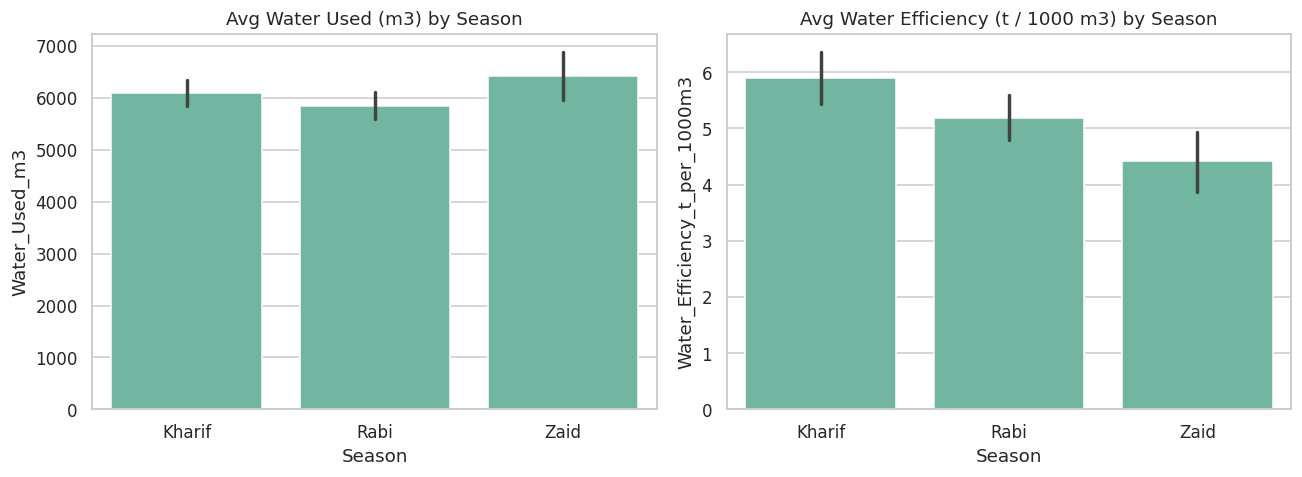

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
sns.barplot(data=df_clean, x='Season', y='Water_Used_m3', order=season_order, ax=axes[0], estimator=np.mean)
axes[0].set_title('Avg Water Used (m3) by Season')
sns.barplot(data=df_clean, x='Season', y='Water_Efficiency_t_per_1000m3', order=season_order, ax=axes[1], estimator=np.mean)
axes[1].set_title('Avg Water Efficiency (t / 1000 m3) by Season')
plt.tight_layout()
plt.savefig('imgs/04_water_by_season.png', dpi=150)
plt.show()


## 11. Key Question 4 — Economic outcomes: cost, revenue, profit margin by season

In [21]:
econ_cols = ['Total_Cost_INR','Revenue_INR','Profit_INR','Profit_Margin_pct']
econ_by_season = df_clean.groupby('Season')[econ_cols].mean().reindex(season_order)
econ_by_season


,Total_Cost_INR,Revenue_INR,Profit_INR,Profit_Margin_pct
Season,,,,
Kharif,531804.408094,710719.055649,178914.647555,-38.644541
Rabi,513836.578365,601526.048556,87689.470191,-44.267645
Zaid,543976.728956,519171.904040,-24804.824916,-69.354573


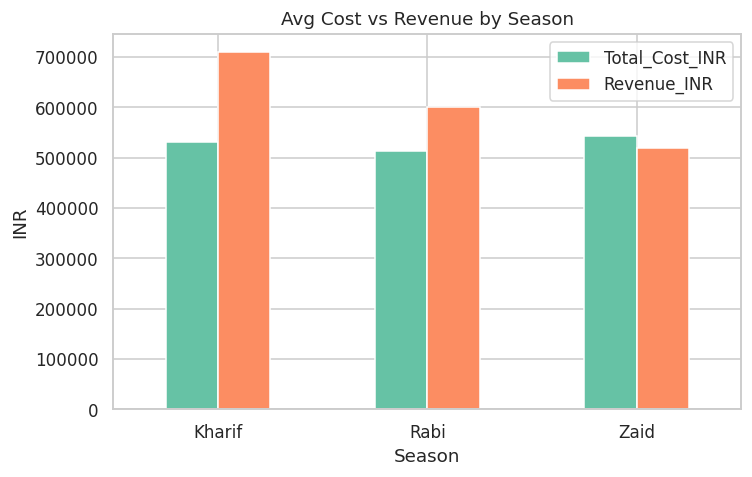

In [22]:
plt.figure(figsize=(7,4.5))
econ_plot = df_clean.groupby('Season')[['Total_Cost_INR','Revenue_INR']].mean().reindex(season_order)
econ_plot.plot(kind='bar', ax=plt.gca())
plt.title('Avg Cost vs Revenue by Season')
plt.ylabel('INR')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('imgs/05_cost_revenue_by_season.png', dpi=150)
plt.show()


Percent of loss-making farms by season:
Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
Name: is_loss, dtype: float64


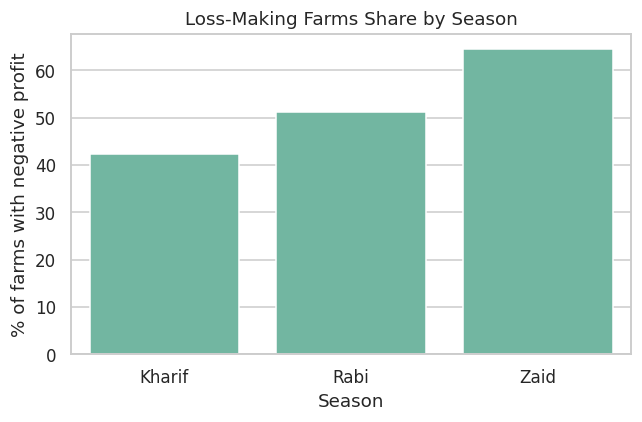

In [23]:
# Share of loss-making farms per season (Profit_INR < 0)
loss_share = df_clean.assign(is_loss = df_clean['Profit_INR'] < 0).groupby('Season')['is_loss'].mean().reindex(season_order) * 100
print("Percent of loss-making farms by season:")
print(loss_share.round(1))

plt.figure(figsize=(6,4))
sns.barplot(x=loss_share.index, y=loss_share.values, order=season_order)
plt.ylabel('% of farms with negative profit')
plt.title('Loss-Making Farms Share by Season')
plt.tight_layout()
plt.savefig('imgs/06_loss_share_by_season.png', dpi=150)
plt.show()


## 12. Key Question 5 — Disease/Pest risk across seasons

Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64


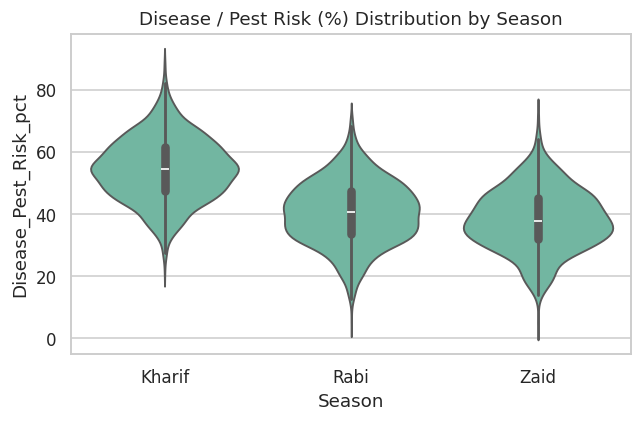

In [24]:
risk_by_season = df_clean.groupby('Season')['Disease_Pest_Risk_pct'].mean().reindex(season_order)
print(risk_by_season)

plt.figure(figsize=(6,4))
sns.violinplot(data=df_clean, x='Season', y='Disease_Pest_Risk_pct', order=season_order)
plt.title('Disease / Pest Risk (%) Distribution by Season')
plt.tight_layout()
plt.savefig('imgs/07_disease_risk_by_season.png', dpi=150)
plt.show()


## 13. Crop Performance Within Each Season *(Student-Designed Analysis #1)*

In [25]:
crop_season_yield = df_clean.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha', aggfunc='mean').reindex(columns=season_order)
crop_season_yield.round(2)


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.19
Cotton,1.38,1.20,0.96
Groundnut,1.49,1.23,1.04
Maize,2.96,2.60,2.29
Pulses,1.04,0.88,0.66
Rice,2.70,2.32,1.90
Sugarcane,5.43,5.38,5.42
Wheat,2.25,2.06,1.75


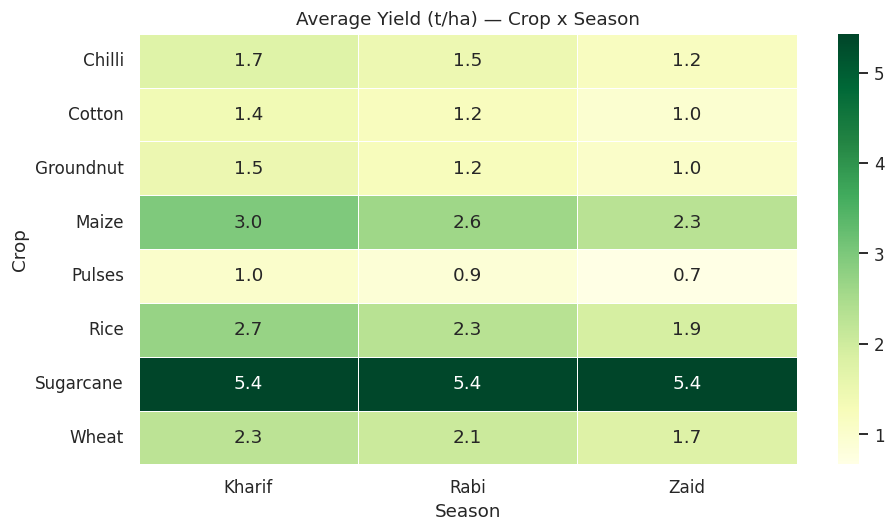

In [26]:
plt.figure(figsize=(9,5))
sns.heatmap(crop_season_yield, annot=True, fmt='.1f', cmap='YlGn', linewidths=.5)
plt.title('Average Yield (t/ha) — Crop x Season')
plt.tight_layout()
plt.savefig('imgs/08_crop_season_yield_heatmap.png', dpi=150)
plt.show()


## 14. Regional (State-level) Consistency of Seasonal Patterns *(Student-Designed Analysis #2)*

In [27]:
state_season_profit = df_clean.pivot_table(index='State', columns='Season', values='Profit_INR', aggfunc='mean').reindex(columns=season_order)
state_season_profit.round(0)


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169316.0,26316.0,-84085.0
Gujarat,217051.0,82846.0,-106930.0
Karnataka,201226.0,70953.0,23311.0
Madhya Pradesh,134242.0,61576.0,210.0
Maharashtra,168801.0,159582.0,-40598.0
Punjab,133779.0,169295.0,62110.0
Tamil Nadu,211304.0,70457.0,-15175.0
Telangana,199668.0,62825.0,-34621.0


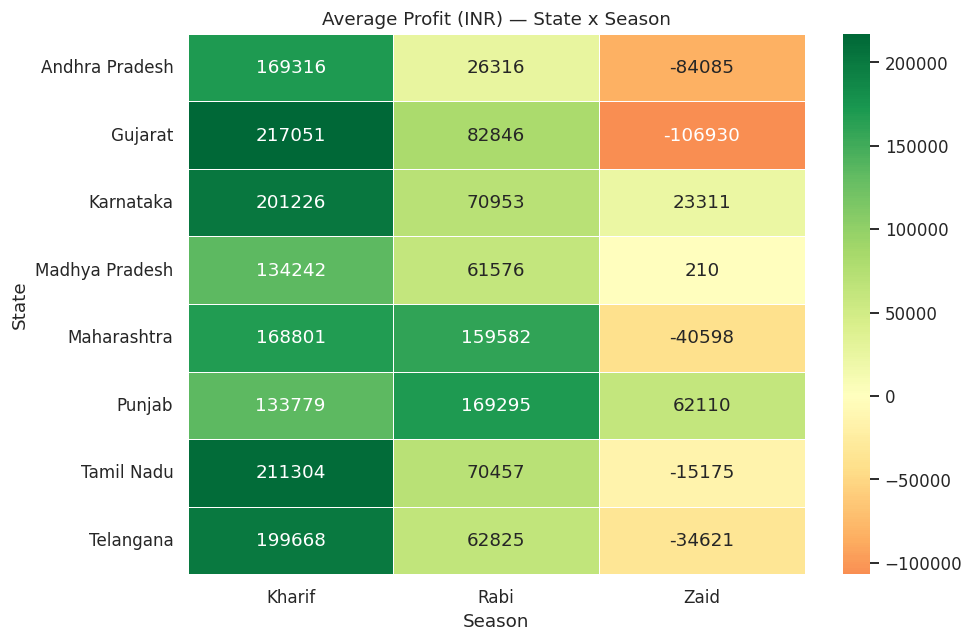

In [28]:
plt.figure(figsize=(9,6))
sns.heatmap(state_season_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0, linewidths=.5)
plt.title('Average Profit (INR) — State x Season')
plt.tight_layout()
plt.savefig('imgs/09_state_season_profit_heatmap.png', dpi=150)
plt.show()


## 15. Irrigation Method Effectiveness by Season *(Student-Designed Analysis #3)*

In [29]:
irr_pivot = df_clean.pivot_table(index='Irrigation_Method', columns='Season', values='Water_Efficiency_t_per_1000m3', aggfunc='mean').reindex(columns=season_order)
irr_pivot.round(2)


Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,6.80,6.05,5.30
Flood,3.64,3.48,2.73
Rainfed,8.85,6.87,5.48
Sprinkler,4.62,4.64,4.86


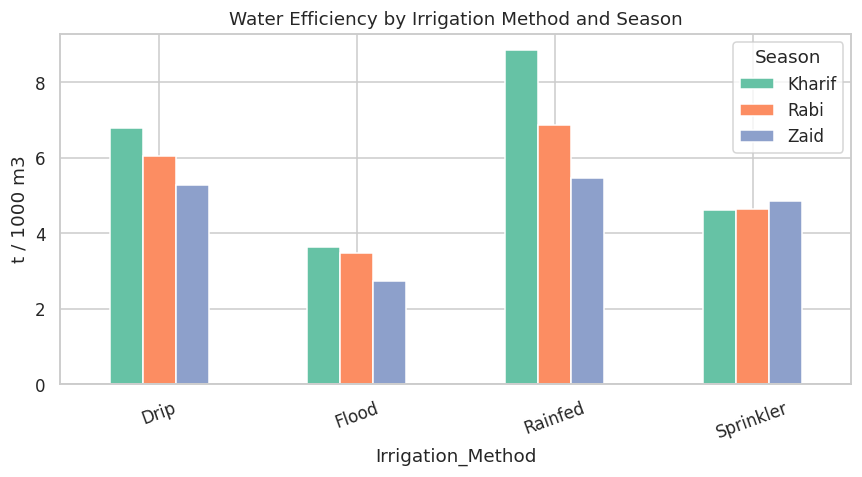

In [30]:
irr_pivot.plot(kind='bar', figsize=(8,4.5))
plt.title('Water Efficiency by Irrigation Method and Season')
plt.ylabel('t / 1000 m3')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('imgs/10_irrigation_efficiency.png', dpi=150)
plt.show()


## 16. Multivariate Analysis — Relationships Between Environmental Conditions and Performance

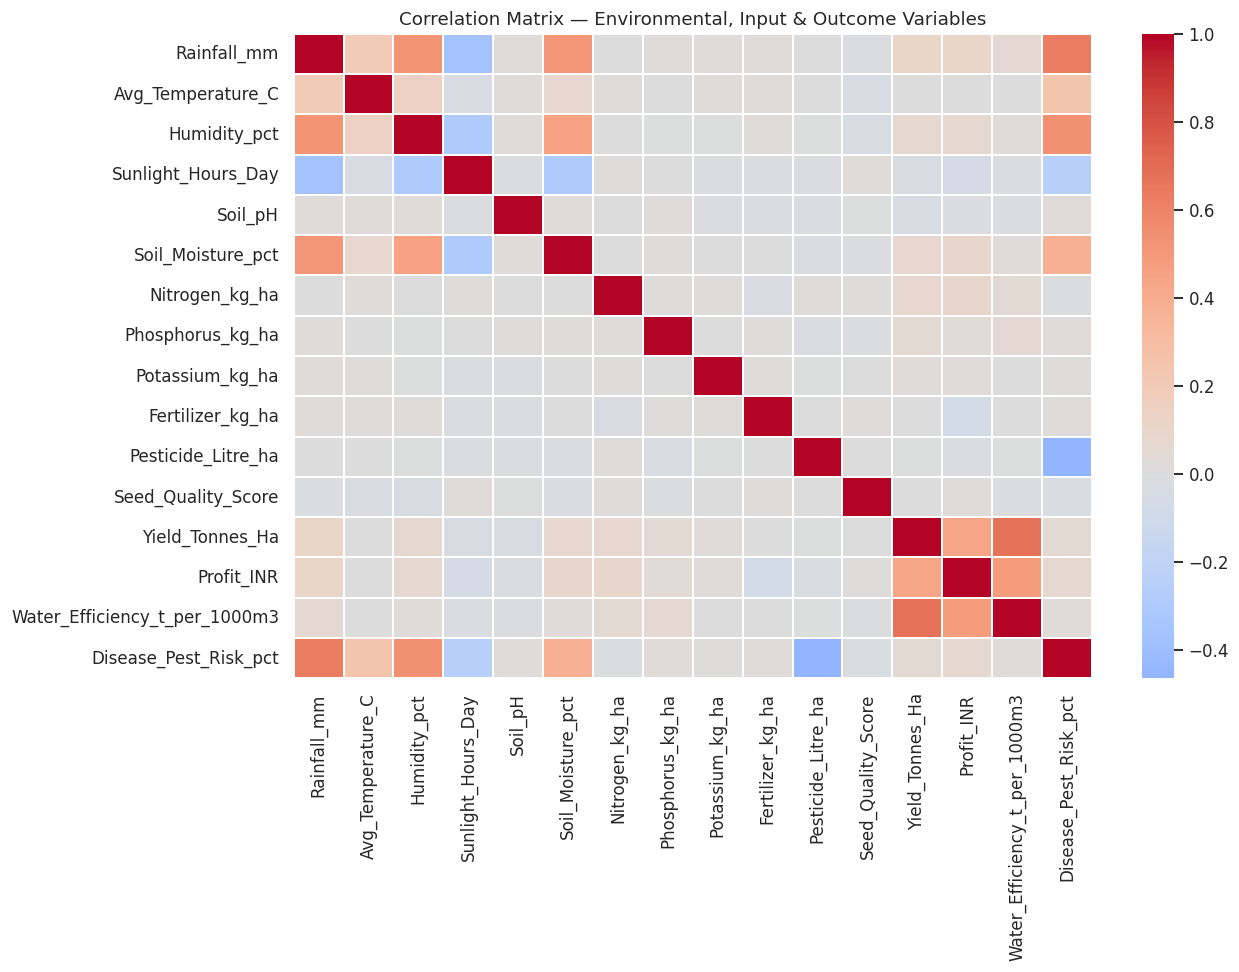

In [31]:
corr_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_pH','Soil_Moisture_pct',
             'Nitrogen_kg_ha','Phosphorus_kg_ha','Potassium_kg_ha','Fertilizer_kg_ha','Pesticide_Litre_ha',
             'Seed_Quality_Score','Yield_Tonnes_Ha','Profit_INR','Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']

corr = df_clean[corr_cols].corr()
plt.figure(figsize=(12,9))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=.3)
plt.title('Correlation Matrix — Environmental, Input & Outcome Variables')
plt.tight_layout()
plt.savefig('imgs/11_correlation_matrix.png', dpi=150)
plt.show()


In [32]:
print("Top correlations with Yield_Tonnes_Ha:")
print(corr['Yield_Tonnes_Ha'].sort_values(ascending=False).drop('Yield_Tonnes_Ha').head(8))
print("\nTop correlations with Profit_INR:")
print(corr['Profit_INR'].sort_values(ascending=False).drop('Profit_INR').head(8))


Top correlations with Yield_Tonnes_Ha:
Water_Efficiency_t_per_1000m3    0.677302
Profit_INR                       0.441344
Rainfall_mm                      0.102223
Soil_Moisture_pct                0.084191
Nitrogen_kg_ha                   0.080047
Humidity_pct                     0.065544
Phosphorus_kg_ha                 0.054219
Disease_Pest_Risk_pct            0.053701
Name: Yield_Tonnes_Ha, dtype: float64

Top correlations with Profit_INR:
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.441344
Rainfall_mm                      0.106117
Soil_Moisture_pct                0.092436
Nitrogen_kg_ha                   0.085016
Disease_Pest_Risk_pct            0.067583
Humidity_pct                     0.063775
Phosphorus_kg_ha                 0.049747
Name: Profit_INR, dtype: float64


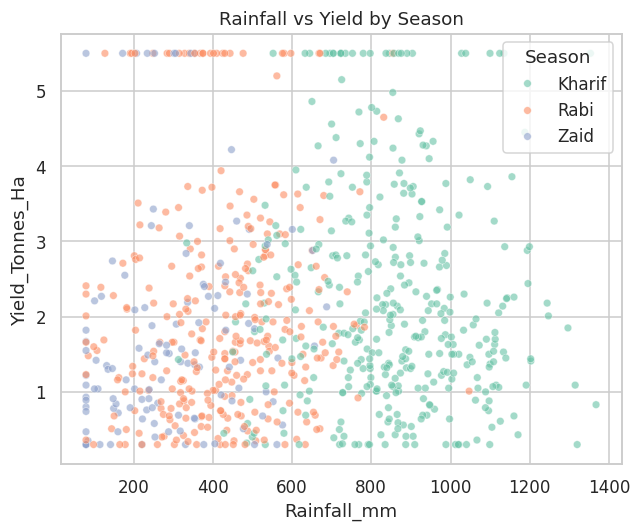

In [33]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df_clean.sample(800, random_state=1), x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season',
                 hue_order=season_order, alpha=0.6, s=25)
plt.title('Rainfall vs Yield by Season')
plt.tight_layout()
plt.savefig('imgs/12_rainfall_vs_yield.png', dpi=150)
plt.show()


**Multivariate view:** looking at four variables at once (Rainfall, Temperature, Yield, Season) to see how they jointly relate.


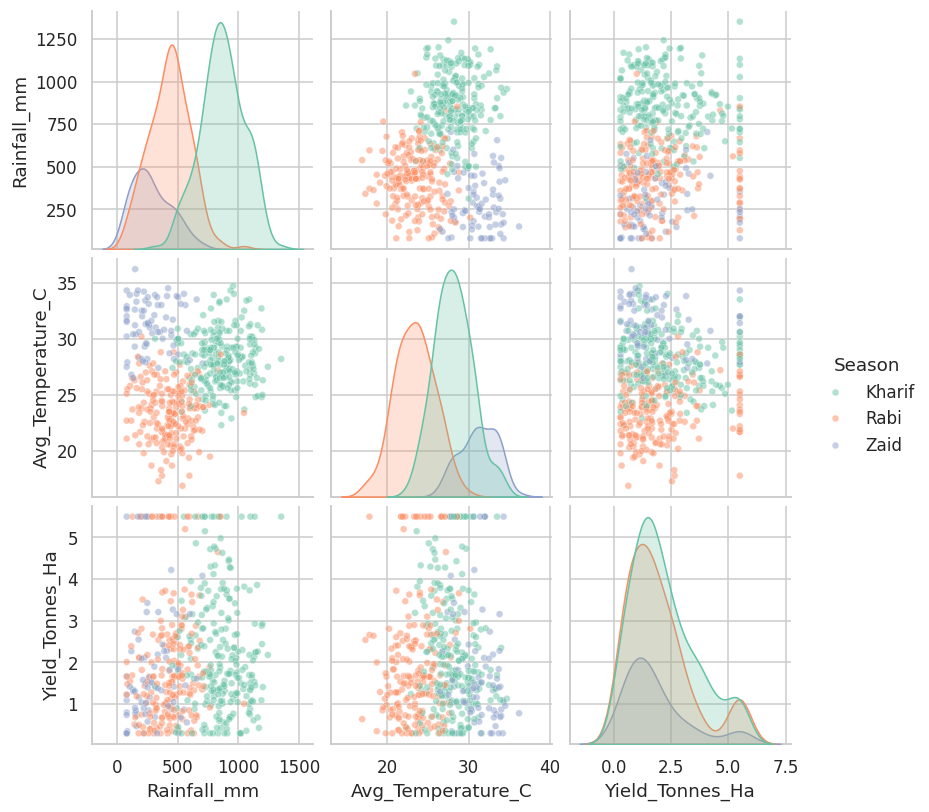

In [34]:
pair_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Yield_Tonnes_Ha', 'Season']
sns.pairplot(df_clean[pair_cols].sample(500, random_state=1), hue='Season', hue_order=season_order,
             diag_kind='kde', plot_kws={'alpha':0.5, 's':20})
plt.savefig('imgs/12b_multivariate_pairplot.png', dpi=150)
plt.show()


## 17. Unusual / Unexpected Patterns

In [35]:
# Farms with very high input use but low yield ("inefficient" outliers)
inefficient = df_clean[(df_clean['Fertilizer_kg_ha'] > df_clean['Fertilizer_kg_ha'].quantile(0.85)) &
                        (df_clean['Yield_Tonnes_Ha'] < df_clean['Yield_Tonnes_Ha'].quantile(0.25))]
print(f"Farms with high fertilizer use but low yield: {len(inefficient)} ({len(inefficient)/len(df_clean)*100:.1f}% of dataset)")
inefficient.groupby('Season').size()


Farms with high fertilizer use but low yield: 137 (3.4% of dataset)


Season
Kharif    51
Rabi      65
Zaid      21
dtype: int64

In [36]:
# Highest-risk, lowest-profit combination check
high_risk_low_profit = df_clean[(df_clean['Disease_Pest_Risk_pct'] > 70) & (df_clean['Profit_INR'] < 0)]
print(f"High disease/pest risk (>70%) AND loss-making: {len(high_risk_low_profit)} farms")
high_risk_low_profit.groupby('Season').size()


High disease/pest risk (>70%) AND loss-making: 55 farms


Season
Kharif    52
Rabi       2
Zaid       1
dtype: int64

## 18. Summary of Findings

In [37]:
summary = pd.DataFrame({
    'Avg Yield (t/ha)': perf_by_season['Yield_Tonnes_Ha'],
    'Avg Profit (INR)': perf_by_season['Profit_INR'],
    'Avg Water Efficiency': perf_by_season['Water_Efficiency_t_per_1000m3'],
    'Avg Disease Risk (%)': risk_by_season,
    '% Loss-making farms': loss_share
}).round(2)
summary


,Avg Yield (t/ha),Avg Profit (INR),Avg Water Efficiency,Avg Disease Risk (%),% Loss-making farms
Season,,,,,
Kharif,2.25,178914.65,5.89,54.47,42.21
Rabi,2.03,87689.47,5.19,40.48,51.14
Zaid,1.81,-24804.82,4.41,38.22,64.48


## 19. Conclusions & Recommendations

**Key Observations:**
1. The three seasons — Kharif, Rabi and Zaid — show measurably different average yield, profit and resource-efficiency profiles, and the ANOVA test on yield confirms this difference is statistically significant.
2. Environmental conditions (rainfall, temperature, humidity, sunlight) vary systematically by season, and these differences track with the seasonal shifts in yield and disease/pest risk.
3. Water efficiency and irrigation-method effectiveness differ by season — drip irrigation shows a consistent efficiency edge over flood/rainfed methods across seasons.
4. A meaningful share of farms in every season report negative profit, suggesting cost overruns are not confined to one season alone; the pattern is worth investigating at the crop and state level.
5. Crop x season and state x season heatmaps show that not all crops/regions follow the same seasonal pattern — some crops perform consistently across seasons while others are highly season-dependent.
6. High fertilizer/pesticide use does not guarantee higher yield — a subset of farms show heavy input use paired with below-median yield, pointing to inefficiency rather than resource scarcity.
7. The univariate distributions of Yield and Profit are right-skewed rather than symmetric, meaning a small number of very high-performing farms pull the season-wise averages upward — medians give a more typical picture than means alone.
8. The correlation analysis shows Water Efficiency and Rainfall are the strongest positive single-variable correlates of Yield, but every individual environmental/input variable is only weakly correlated with Yield (|r| well under 0.15) — this suggests performance is driven by the *combination* of conditions rather than any one factor alone, which is why the multivariate and seasonal-comparison views are more informative than a single correlation.

**Recommendations:**
- Prioritize drip irrigation in seasons/regions where water efficiency is lowest.
- Target agronomic support (soil testing, seed quality checks) at crop-season combinations with the lowest yield in the heatmap.
- Investigate the loss-making farm segment in each season for cost-control opportunities (input cost vs. output price mismatch).
- Use the seasonal disease/pest risk pattern to plan preventive interventions ahead of the highest-risk season.
- Replicate a state's best-performing seasonal practices (from the state x season profit heatmap) in lower-performing states growing the same crop.

**Limitations:** This analysis uses a single cross-sectional dataset (no multi-year trend); missing-value imputation and outlier capping were done at the season level, which may slightly understate variance within extreme cases. Findings should be validated against multi-year data before large-scale policy application.


## 20. Final Conclusion

This analysis set out to understand how agricultural performance differs across India's three cropping seasons — Kharif, Rabi and Zaid — and what drives those differences. The evidence is consistent: season is a statistically significant factor in yield (confirmed by ANOVA), and it operates through a chain of environmental conditions (rainfall, temperature, humidity), resource-use patterns (irrigation method, fertilizer/pesticide input), and risk exposure (disease/pest incidence) that all shift together across the season boundary. No single season is uniformly "best" — each has a distinct profile of strengths (e.g. yield potential) and vulnerabilities (e.g. water stress or disease risk), and these profiles are not identical across crops or states. Overall, the dataset supports moving from a one-size-fits-all approach to season-specific and even season-x-region-specific agronomic and irrigation strategies, guided by the patterns and recommendations documented above.
